In [1]:
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI
from typing import TypedDict , List ,Optional ,Literal ,Annotated
from langchain_core.documents import Document
from langchain_core.messages import BaseMessage
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from pathlib import Path
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import AIMessage , HumanMessage , BaseMessage,RemoveMessage
import json
from langchain_community.document_loaders import PyPDFLoader,TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter , CharacterTextSplitter
from langgraph.graph import StateGraph , START , END
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import add_messages
from pydantic import BaseModel ,Field
from langgraph.store.base import BaseStore
from langchain_core.runnables import RunnableConfig
from langgraph.store.memory import InMemoryStore

In [7]:
store = InMemoryStore()

In [10]:
from utils import get_kb_retriever
get_kb_retriever()
print("FAISS ready")

Loading FAISS index from disk...
FAISS ready


In [4]:
llm = ChatOpenAI(model="gpt-4o-mini")
llm.invoke("Hello")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_2767f2907f', 'id': 'chatcmpl-DoucHBASFKNpye3GQkhF6g3GWjusW', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ead72-34fc-7423-99c1-09e251391497-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [130]:
def load_docs_for_creating_chunks(folder_path : str) : 
    docs = [] 
    for file_path in Path(folder_path).iterdir() : 
        if file_path.suffix == ".pdf" : 
            loader = PyPDFLoader(str(file_path))
            docs.extend(loader.load())
        elif file_path.suffix == ".txt" :
            loader = TextLoader(str(file_path) , encoding="utf-8")
            docs.extend(loader.load())
        elif file_path.suffix == ".json" :
            with open(file_path , "r" , encoding="utf-8") as f :
                data = json.load(f)
            content = json.dumps(data , ensure_ascii=False , indent=2)
            docs.append(Document(page_content=content, metadata={"source": str(file_path)}))

    return docs

In [131]:
def get_vector_store_obj(embedding_model : str , docs : list[Document]) : 
    embedder = OpenAIEmbeddings(model=embedding_model)
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000 , chunk_overlap=200)
    chunks = text_splitter.split_documents(docs)

    for d in chunks:
        d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

    print(f"Total Chunks : {len(chunks)}")

    vector_store = FAISS.from_documents(chunks ,embedding=embedder)

    return vector_store



In [132]:
def get_retiriever(vector_store_obj) : 
    retriever = vector_store_obj.as_retriever(
        search_type="mmr" , #Maximal Marginal Relevance
        search_kwargs={
            "k": 5,  # final docs returned
            "fetch_k": 20 ,# candidate pool before diversity filter
            "lambda_mult": 0.7 # closer to 1 = relevance, closer to 0 = diversity
        }
    )
    return retriever

In [133]:
def retriever_setup(folder_path : str , embedding_model : str) : 
    docs = load_docs_for_creating_chunks(folder_path)
    vector_store_obj = get_vector_store_obj(embedding_model , docs)
    retriever = get_retiriever(vector_store_obj)

    return retriever

In [134]:
retriever = retriever_setup("./kb" , "text-embedding-3-large")

Total Chunks : 3754


In [136]:
retriever.invoke("linear regression L1 regularization")[0].page_content

'non-linear least-squares problems.\nbLASSO (least absolute shrinkage and selection operator) is a regression analysis method that per-\nforms both variable selection and regularization in order to enhance the prediction accuracy and inter-\npretability of the statistical model it produces. It includes an L1 penalty term: minw Q(X, y; w) + λ∥w∥1.\nIt was originally developed in Geophysics [68, (Santosa-Symes, 1986)], and later independently redis-\ncovered and popularized in 1996 by Robert Tibshirani [75], who coined the term and provided further\ninsights into the observed performance.\ncThe elastic net regularization is a regularized regression method that linearly combines the L1\nand L2 penalties of the LASSO and ridge methods, particularly in the fitting of linear or logistic regres-\nsion models.\nWe will see how L1-regularization can reduce overfitting (serving as a fea-\nture selection method).'

In [163]:
class Chat(TypedDict) :
    messages : Annotated[List[BaseMessage] ,add_messages]
    docs : list[Document]

    summary : Optional[str]


In [170]:
class ShouldRetrieve(BaseModel) :
    retrieve : bool = Field(description="Whether to retrieve from vector store or not")
def should_retrieve(state : Chat) -> bool : 
    if len(state.get("messages", [])) == 0 :
        return False
    
    last_message = state["messages"][-1]

    if isinstance(last_message , HumanMessage) :
         
        res = llm.with_structured_output(ShouldRetrieve).invoke("You are an helpful assistant which helps user to learn Machine Learning,Deep Learning and Machine learning maths.If the query is related to these topics then return true else return false. Query : " + last_message.content)
        return res.retrieve
    
    return False

In [138]:
def retireve_docs(state) : 
    query = state["messages"][-1].content

    print(query)

    return {
        "docs" : retriever.invoke(query)
    }
    

In [139]:
Document(page_content="hello world" , metadata={"source" : "file1.txt"})

Document(metadata={'source': 'file1.txt'}, page_content='hello world')

In [166]:
def chat_node(state: Chat, config: RunnableConfig, store: BaseStore):
    user_id = config.get("configurable", {}).get("user_id", "default")
    
    d = {}
    for itm in store.search(("user", user_id)):
        category = itm.namespace[2]
        if category not in d:
            d[category] = {}
        d[category][itm.key] = itm.value['data']

    docs = state.get("docs") or []

    prompt = """You are a specialized Machine Learning assistant.

You have access to a knowledge base containing ONLY:
- Machine Learning concepts and algorithms
- Deep Learning architectures and techniques
- ML Mathematics (linear algebra, calculus, probability, statistics)
- Model training, evaluation, and optimization
- Neural networks, backpropagation, activation functions

BEHAVIOR:
- If the user asks about ML/DL/math → answer strictly using the retrieved documents only
- If the answer is not found in the documents → say "I don't have enough information in my knowledge base to answer this."
- If the user asks something outside ML/DL scope (weather, sports, cooking etc) → politely say "I can only answer questions related to Machine Learning, Deep Learning, and ML Mathematics."
- If the user is greeting or sharing personal info → respond naturally and friendly
- Never make up ML facts or concepts not present in the documents
"""

    if docs:
        prompt += "\n\nRetrieved Documents:\n\n" + "\n\n".join(
            [f"Document {i}: {doc.page_content}" for i, doc in enumerate(docs, 1)]
        )
    else:
        prompt += "\n\nRetrieved Documents:\n\nNone"

    prompt += f"\n\nUser Details: {d if d else 'None'}"
    prompt += f"\n\nQuestion: {state['messages'][-1].content}"

    summary = state.get('summary', '')
    messages_text = "\n".join(msg.content for msg in state["messages"])
    chat_context = f"{summary}\n{messages_text}".strip()
    prompt += f"\n\nChat Context:\n\n{chat_context}" if chat_context else ""
    print(prompt)
    res = llm.invoke(prompt)
    return {"messages": [AIMessage(content=res.content)]}

In [141]:
def should_summarize(state):
    return len(state["messages"]) >= 10

In [142]:
class LTMData(BaseModel) :
    category : Literal["details" , "preferences" , "goals"] = Field(...,description="Category of the information.",examples=["preferences"])
    text : str = Field(... , description="The important information to be stored in LTM.")
    key: str = Field(..., description="Short snake_case identifier for this fact. e.g. 'name', 'location', 'preferred_language', 'current_project'. Must be consistent — same concept always gets same key.")

class LTMStorageNodeOutput(BaseModel) :
    should_store : bool = Field(... , description="Whether to store any of the important information in long-term memory.")
    ltm_data : Optional[List[LTMData]] = Field(None , description="The important information to be stored in LTM along with its category.")

class SummarizeAndSaveToLTM(BaseModel) :
    summary : str = Field(... , description="The updated summary of the conversation so far.")
    ltm_output : Optional[LTMStorageNodeOutput] = Field(None , description="The important information to be stored in LTM along with its category.")
     

    

def summarize_node(state : Chat , config : RunnableConfig , store : BaseStore) :

    existing_summary = state.get("summary", "")
    user_id = config.get("configurable", {}).get("user_id", "default")

    prompt = """You are maintaining a concise, evolving summary of a conversation AND extracting important information for long-term memory.

You must do TWO things:

---
TASK 1 — UPDATE SUMMARY:
- Combine the existing summary with the new conversation.
- Preserve important context from the existing summary.
- If new information updates or contradicts old information, MODIFY accordingly.
- Remove redundant, outdated, or less relevant details.
- Keep only the most important and up-to-date information.
- Ensure the final summary is clear, coherent, and under 100 words.
- Always capture the USER'S INTENT — what the user is trying to ask, solve, or achieve.
- Track key decisions, problems, and outcomes.

Focus on:
- User intent (main problem/question)
- Key facts and context
- Decisions or solutions discussed

---
TASK 2 — EXTRACT LONG-TERM MEMORY:
Check if the conversation contains any personal information worth remembering across sessions.

Categories:
- details: personal facts (name, age, location, occupation)
- preferences: likes, dislikes, preferred tools, style choices
- goals: what the user is building, learning, or trying to achieve

Rules:
- Only store clear, explicit facts — not assumptions
- If nothing worth storing, set should_store to false and ltm_data to null
- Extract ALL clear facts found in the conversation, not just one
- Each fact gets its own entry in ltm_data
- If a fact was already mentioned in the existing summary, do NOT store it again
- For details/preferences: use consistent keys like 'name', 'location' so updates overwrite cleanly
- For goals: use descriptive keys like 'goal_learn_ml', 'goal_build_chatbot' since users can have multiple
"""

    if existing_summary:
        prompt += "\n\nExisting Summary:\n" + existing_summary

    prompt += "\n\nNew Conversation:\n" + "\n".join(
    "User: " + msg.content if isinstance(msg, HumanMessage) else "AI: " + msg.content
    for msg in state["messages"]
    )

    llm_with_structured_output = llm.with_structured_output(SummarizeAndSaveToLTM)
    res : SummarizeAndSaveToLTM = llm_with_structured_output.invoke(prompt)
    messages_to_delete = state["messages"][:-2]  # Keep the last 2 messages for context

    updatesSummary = res.summary
    ltm_output = res.ltm_output
    # safer
    
    if ltm_output and ltm_output.should_store :
        for item in ltm_output.ltm_data or [] :
            store.put(namespace=("user" ,user_id,item.category) , key=item.key , value={"data": item.text})


    return {
        "summary": updatesSummary ,
        "messages" : [RemoveMessage(id=msg.id) for msg in messages_to_delete]
    }

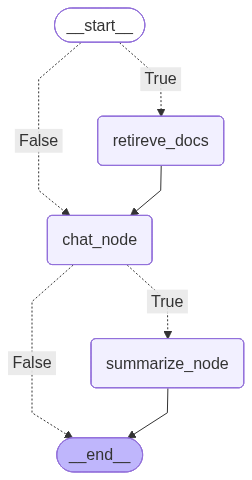

In [171]:
builder = StateGraph(Chat)

builder.add_node("retireve_docs" , retireve_docs)
builder.add_node("chat_node" , chat_node)
builder.add_node("summarize_node" , summarize_node)

builder.add_conditional_edges(START , should_retrieve , { 
    True : "retireve_docs" ,
    False : "chat_node"
})
builder.add_edge("retireve_docs" , "chat_node")
builder.add_conditional_edges("chat_node" , should_summarize , {
    True : "summarize_node" ,
    False : END
})
builder.add_edge("summarize_node", END)

checkpoint_saver = InMemorySaver()

graph = builder.compile(checkpointer=checkpoint_saver , store=store)
graph

In [195]:
res= graph.invoke({
    "messages" : [HumanMessage(content="whats neural network explain simply?") ]
} ,
config={
    "configurable" : {
        "thread_id" : "test_thread_4",
        "user_id" : "user_67"
    }
})

whats neural network explain simply?
You are a specialized Machine Learning assistant.

You have access to a knowledge base containing ONLY:
- Machine Learning concepts and algorithms
- Deep Learning architectures and techniques
- ML Mathematics (linear algebra, calculus, probability, statistics)
- Model training, evaluation, and optimization
- Neural networks, backpropagation, activation functions

BEHAVIOR:
- If the user asks about ML/DL/math → answer strictly using the retrieved documents only
- If the answer is not found in the documents → say "I don't have enough information in my knowledge base to answer this."
- If the user asks something outside ML/DL scope (weather, sports, cooking etc) → politely say "I can only answer questions related to Machine Learning, Deep Learning, and ML Mathematics."
- If the user is greeting or sharing personal info → respond naturally and friendly
- Never make up ML facts or concepts not present in the documents


Retrieved Documents:

Document 1: 

In [198]:
from IPython.display import Markdown, display
display(Markdown(res["messages"][-1].content))

A neural network is a computational model inspired by how biological brains work. It consists of interconnected groups of nodes, called neurons, which process information. Each neuron takes input, applies a mathematical transformation, and produces an output. 

Neural networks can learn complex patterns by adjusting the connections (weights) between neurons based on the data they are trained on. They are particularly good at handling non-linear relationships and can be used for tasks like classification and regression. Essentially, you can think of a neural network as a function approximator that learns from data to make predictions or decisions.

In [191]:
res["summary"]

"User, Mantha, is an intern at Ray Secure Innovation, focused on learning machine learning concepts such as neural networks and backpropagation. They prefer simple explanations and sought definitions related to architecture within deep learning. Although the AI couldn't address their architecture-related queries, it emphasized its domain focus. The conversation highlighted Mantha's inquisitive nature and desire for clarity in understanding complexities of machine learning."

In [193]:
results = store.search(("user", "user_67"))    
results

[Item(namespace=['user', 'user_67', 'details'], key='name', value={'data': 'Mantha is an intern at Ray Secure Innovation.'}, created_at='2026-04-30T05:48:16.284121+00:00', updated_at='2026-04-30T05:48:16.284124+00:00', score=None),
 Item(namespace=['user', 'user_67', 'details'], key='occupation', value={'data': 'User is an intern at Ray Secure Innovation.'}, created_at='2026-04-30T05:45:16.749604+00:00', updated_at='2026-04-30T05:45:16.749604+00:00', score=None),
 Item(namespace=['user', 'user_67', 'goals'], key='goal_learn_ml', value={'data': 'Mantha is learning about machine learning concepts.'}, created_at='2026-04-30T05:48:16.284137+00:00', updated_at='2026-04-30T05:48:16.284137+00:00', score=None),
 Item(namespace=['user', 'user_67', 'preferences'], key='prefer_linear_regression', value={'data': 'User wants to learn about linear regression.'}, created_at='2026-04-30T05:26:07.953082+00:00', updated_at='2026-04-30T05:26:07.953082+00:00', score=None)]

In [94]:
d = {}
for itm in store.search(("user", "user_1212")) :
    category = itm.namespace[2]
    if category not in d :
        d[category] = {}
    d[category][itm.key] = itm.value["data"]

d

{'details': {'name': "User's name is Manthan",
  'occupation': 'User works at Ray Secure Innovations',
  'occupation_details': 'User is a full stack and AI developer',
  'current_project': 'User works on the HSIA platform'},
 'preferences': {'preferred_tools': 'User uses Golang and Next.js for development'},
 'goals': {'goal_learn_langgraph': 'User is learning LangGraph',
  'goal_create_chatbot': 'User is creating a chatbot'}}

In [95]:
res["summary"]

"User's name is Manthan, and he works as a full stack and AI developer at Ray Secure Innovations. He is working on the HSIA platform and uses Golang and Next.js for development. Additionally, he is learning LangGraph and is in the process of creating a chatbot."

In [194]:
retriever.invoke("whats neural network ")[0].page_content

'thefunctionsthatbiologicalneuronscompute.However,modernneuralnetwork\nresearchisguidedbymanymathematicalandengineeringdisciplines,andthe\ngoalofneuralnetworksisnottoperfectlymodelthebrain.Itisbesttothinkof\nfeedforwardnetworksasfunctionapproximationmachinesthataredesignedto\nachievestatisticalgeneralization,occasionallydrawingsomeinsightsfromwhatwe\nknowaboutthebrain,ratherthanasmodelsofbrainfunction.\nOnewaytounderstandfeedforwardnetworksistobeginwithlinearmodels\nandconsiderhowtoovercometheirlimitations. Linearmodels,suchaslogistic\nregressionandlinearregression,areappealingbecausetheymaybeﬁteﬃciently\nandreliably,eitherinclosedformorwithconvexoptimization.Linearmodelsalso\nhavetheobviousdefectthatthemodelcapacityislimitedtolinearfunctions,so\nthemodelcannotunderstandtheinteractionbetweenanytwoinputvariables.\nToextendlinearmodelstorepresentnonlinearfunctionsofx,wecanapply\nthelinearmodelnottoxitselfbuttoatransformedinputφ(x),whereφisa\n169'